In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import random 
import joblib 

from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import (
    Input, Dense, Dropout, BatchNormalization, Activation, Add
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import Huber
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras import regularizers # L2 için


from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestRegressor 
from sklearn.linear_model import Ridge 


In [2]:
#-------------------------------------------------------------------------------
# Blok 1 Fonksiyonları: MLP Modelini Oluşturma, Özellik Seçimi, Eğitim, Değerlendirme ve Kaydetme
#-------------------------------------------------------------------------------
def build_mlp_model_with_residual(input_dim, learning_rate=0.001, dropout_rate=0.1, l2_reg_val=1e-5):
    """Residual bağlantılı bir Multi-Layer Perceptron (MLP) modeli oluşturur."""
    l2_reg = regularizers.l2(l2_reg_val)
    inputs = Input(shape=(input_dim,))

    # İlk blok
    x = Dense(512, kernel_regularizer=l2_reg)(inputs)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(dropout_rate)(x)

    # Residual Blok
    skip = x
    x = Dense(512, activation='elu', kernel_regularizer=l2_reg)(x)
    x = BatchNormalization()(x)
    x = Dense(512, activation='elu', kernel_regularizer=l2_reg)(x) # İkinci bir dense katman eklendi (opsiyonel)
    x = Add()([x, skip]) # Residual bağlantı

    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(dropout_rate)(x)

    # Sonraki katmanlar
    x = Dense(256, activation='relu', kernel_regularizer=l2_reg)(x)
    x = BatchNormalization()(x)
    x = Dropout(dropout_rate)(x)

    x = Dense(128, activation='relu', kernel_regularizer=l2_reg)(x)
    
    outputs = Dense(1, activation='linear', kernel_regularizer=l2_reg)(x) # Regresyon için lineer aktivasyon

    model = Model(inputs, outputs)
    optimizer = Adam(learning_rate=learning_rate)   
    model.compile(
        optimizer=optimizer,
        loss=Huber(delta=1.0, reduction='sum_over_batch_size'), 
        metrics=['mae']
    )
    return model

In [3]:
def train_evaluate_save_mlp_model( 
    data_path='veri.csv',
    target_column='delta_e',
    feature_selection_method='lasso', 
    # LASSO için parametreler
    lasso_alpha=0.0001,
    # RFE için parametreler
    rfe_estimator_type='rf', # 'rf' (RandomForestRegressor) veya 'linear' (Ridge) olabilir
    n_features_to_select_rfe=None, # RFE ile seçilecek özellik sayısı
    rfe_step=0.1, # RFE'de her adımda çıkarılacak özellik oranı
    # Random Forest Importance için parametreler
    n_features_to_select_rf=None, # RF importance ile seçilecek özellik sayısı
    rf_n_estimators=100, # RF için ağaç sayısı
    test_size=0.2,
    random_state=42,
    base_filename='mlp_delta_e_model',
    create_model_fn=build_mlp_model_with_residual,
    epochs=100,
    batch_size=512,
    learning_rate=0.001,
    dropout_rate=0.1,
    l2_reg_val=1e-5
):
    """
    Veri yükler, belirtilen yöntemle özellik seçimi yapar, MLP modelini eğitir, değerlendirir ve kaydeder.
    """
    # Dinamik dosya adları
    model_filename = f'{base_filename}_{feature_selection_method}.keras'
    scaler_filename = f'mlp_scaler_{feature_selection_method}.joblib'
    features_filename = f'mlp_model_features_{feature_selection_method}.joblib'

    print(f"Veri '{data_path}' dosyasından yükleniyor...")
    try:
        df = pd.read_csv(data_path)
        print(f"Veri '{data_path}' dosyasından yüklendi. Orijinal boyut: {df.shape}")
    except FileNotFoundError:
        print(f"HATA: '{data_path}' bulunamadı.")
        return None, None, None
    except Exception as e:
        print(f"Veri yüklenirken bir hata oluştu: {e}")
        return None, None, None

    if target_column not in df.columns:
        print(f"HATA: Hedef sütun '{target_column}' veri setinde bulunamadı.")
        return None, None, None

    X_original = df.drop(columns=[target_column])
    y_original = df[target_column]
    print(f"İlk özellik sayısı (hedef hariç): {X_original.shape[1]}")

    if X_original.shape[1] == 0:
        print("HATA: Veri setinde hiç özellik bulunmuyor.")
        return None, None, None

    # 1) Özellik Seçimi için Eğitim Verisi Hazırlığı (LASSO, RFE, RF için ortak)
    # Bu aşamada test setini ayırmıyoruz, tüm X_original üzerinde özellik seçimi yapabiliriz
    # veya sadece bir eğitim alt kümesi üzerinde yapabiliriz.
    # Şimdilik, tüm X_original'ı kullanacağız ve sonra nihai train/test split yapacağız.
    # Ancak, eğer özellik seçimi çok maliyetliyse, bir alt küme (X_train_pre_selection) kullanılabilir.
    # Basitlik adına, önce X_original'ı ölçekleyip sonra özellik seçimi yapacağız.

    scaler_for_feature_selection = StandardScaler()
    X_original_scaled = scaler_for_feature_selection.fit_transform(X_original)
    # DataFrame'e dönüştürmek, sütun adlarını korumak için RFE ve RF için faydalı olabilir
    X_original_scaled_df = pd.DataFrame(X_original_scaled, columns=X_original.columns)

    selected_feature_names = []

    # 2) Özellik Seçimi
    print(f"\n--- {feature_selection_method.upper()} ile Özellik Seçimi ---")
    if feature_selection_method == 'lasso':
        lasso = Lasso(alpha=lasso_alpha, max_iter=10000, random_state=random_state) # max_iter artırıldı
        lasso.fit(X_original_scaled_df, y_original) # Tüm ölçeklenmiş veri üzerinde fit
        non_zero_indices = np.where(np.abs(lasso.coef_) > 1e-5)[0] # Küçük katsayıları da elemek için eşik
        selected_feature_names = X_original.columns[non_zero_indices].tolist()
        if not selected_feature_names:
             print(f"LASSO (alpha={lasso_alpha}) ile hiç özellik seçilemedi. Alpha değerini düşürmeyi veya eşik değerini (1e-5) değiştirmeyi deneyin.")
             # Alternatif olarak tüm özellikleri kullanmayı düşünebilirsiniz
             # selected_feature_names = X_original.columns.tolist()
             # print("Uyarı: LASSO özellik seçemedi, tüm özellikler kullanılıyor.")
             if not X_original.columns.tolist(): # Hiç özellik yoksa hata ver
                 print("HATA: Hiç özellik yok.")
                 return None, None, None


    elif feature_selection_method == 'rfe':
        if n_features_to_select_rfe is None:
            n_features_to_select_rfe = X_original.shape[1] // 2 # Varsayılan olarak yarısını seç
            if n_features_to_select_rfe == 0 and X_original.shape[1] > 0:
                n_features_to_select_rfe = 1
        
        if n_features_to_select_rfe == 0 or n_features_to_select_rfe > X_original.shape[1]:
            print(f"HATA: RFE için geçersiz özellik sayısı: {n_features_to_select_rfe}. Kullanılabilir özellik sayısı: {X_original.shape[1]}")
            return None, None, None

        if rfe_estimator_type == 'rf':
            estimator = RandomForestRegressor(n_estimators=50, random_state=random_state, n_jobs=-1) # Hız için n_estimators düşürülebilir
        elif rfe_estimator_type == 'linear':
            estimator = Ridge(alpha=1.0, random_state=random_state) # Ridge, Lasso'ya benzer ama L2 kullanır
        else:
            print(f"HATA: Geçersiz RFE estimator tipi: {rfe_estimator_type}")
            return None, None, None
        
        print(f"RFE için estimator: {estimator.__class__.__name__}, Seçilecek özellik sayısı: {n_features_to_select_rfe}")
        selector_rfe = RFE(estimator, n_features_to_select=n_features_to_select_rfe, step=rfe_step, verbose=1)
        selector_rfe.fit(X_original_scaled_df, y_original)
        selected_feature_names = X_original.columns[selector_rfe.support_].tolist()

    elif feature_selection_method == 'rf_importance':
        if n_features_to_select_rf is None:
            n_features_to_select_rf = X_original.shape[1] // 2 # Varsayılan olarak yarısını seç
            if n_features_to_select_rf == 0 and X_original.shape[1] > 0:
                n_features_to_select_rf = 1

        if n_features_to_select_rf == 0 or n_features_to_select_rf > X_original.shape[1]:
            print(f"HATA: RF Importance için geçersiz özellik sayısı: {n_features_to_select_rf}. Kullanılabilir özellik sayısı: {X_original.shape[1]}")
            return None, None, None
        
        print(f"Random Forest ile özellik önem sıralaması. Seçilecek özellik sayısı: {n_features_to_select_rf}")
        rf_selector = RandomForestRegressor(n_estimators=rf_n_estimators, random_state=random_state, n_jobs=-1)
        rf_selector.fit(X_original_scaled_df, y_original)
        importances = rf_selector.feature_importances_
        indices_rf = np.argsort(importances)[::-1] # En önemliden aza doğru sırala
        selected_feature_names = X_original.columns[indices_rf[:n_features_to_select_rf]].tolist()

    else:
        print(f"HATA: Geçersiz özellik seçim yöntemi: {feature_selection_method}")
        return None, None, None

    if not selected_feature_names:
        print(f"HATA: '{feature_selection_method}' yöntemiyle hiç özellik seçilemedi. Parametreleri kontrol edin.")
        # Eğer hiçbir özellik seçilemezse, tüm özellikleri kullanmayı deneyebilirsiniz veya hata verebilirsiniz.
        # Şimdilik hata veriyoruz:
        return None, None, None
        
    print(f"'{feature_selection_method}' ile seçilen önemli değişken sayısı: {len(selected_feature_names)}")
    if selected_feature_names:
        print(f"Seçilen özelliklerden bazıları: {selected_feature_names[:10]}")
    else:
        print("Hiç özellik seçilmedi.")
        return None, None, None


    # 3) Seçilen Özelliklerle Nihai Eğitim-Test Ayrımı
    X_selected_features = X_original[selected_feature_names]
    X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(
        X_selected_features, y_original, test_size=test_size, random_state=random_state
    )

    # Nihai Ölçeklendirme (MLP için)
    # Bu ölçekleyici sadece seçilmiş özellikler üzerinde eğitilir.
    scaler_final_mlp = StandardScaler()
    X_train_scaled = scaler_final_mlp.fit_transform(X_train_final)
    X_test_scaled = scaler_final_mlp.transform(X_test_final)

    input_dim = X_train_scaled.shape[1]
    if input_dim == 0:
        print("HATA: Model için hiç özellik kalmadı (input_dim = 0).")
        return None, None, None
        
    model = create_model_fn(input_dim, learning_rate=learning_rate, dropout_rate=dropout_rate, l2_reg_val=l2_reg_val)
    model.summary()

    # Callbacks
    early_stopping = EarlyStopping(monitor='val_loss', patience=15, verbose=1, restore_best_weights=True) # Patience biraz artırıldı
    model_checkpoint = ModelCheckpoint(model_filename, monitor='val_loss', save_best_only=True, verbose=1)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=7, min_lr=1e-7, verbose=1) # Factor ve patience ayarlandı

    print(f"\nMLP modeli '{feature_selection_method}' özellikleriyle eğitiliyor...")
    history = model.fit(
        X_train_scaled, y_train_final,
        validation_data=(X_test_scaled, y_test_final),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stopping, model_checkpoint, reduce_lr],
        verbose=1
    )
    print("Model eğitimi tamamlandı.")

    model.save(f'{base_filename}_{feature_selection_method}.h5')
    print(f"Model ayrıca h5 formatında da kaydedildi: {base_filename}_{feature_selection_method}.h5")

    try:
        best_model = load_model(model_filename)
        print(f"En iyi model '{model_filename}' dosyasından yüklendi.")
    except Exception as e:
        print(f"En iyi model yüklenirken hata: {e}. Son eğitilen model kullanılacak.")
        best_model = model

    y_pred_train = best_model.predict(X_train_scaled).flatten()
    y_pred_test = best_model.predict(X_test_scaled).flatten()

    print("\n---- Eğitim Seti Performansı ----")
    print(f"MSE:  {mean_squared_error(y_train_final, y_pred_train):.5f}")
    print(f"RMSE: {np.sqrt(mean_squared_error(y_train_final, y_pred_train)):.5f}")
    print(f"MAE:  {mean_absolute_error(y_train_final, y_pred_train):.5f}")
    print(f"R^2:  {r2_score(y_train_final, y_pred_train):.5f}")

    print("\n---- Test Seti Performansı ----")
    print(f"MSE:  {mean_squared_error(y_test_final, y_pred_test):.5f}")
    print(f"RMSE: {np.sqrt(mean_squared_error(y_test_final, y_pred_test)):.5f}")
    print(f"MAE:  {mean_absolute_error(y_test_final, y_pred_test):.5f}")
    print(f"R^2:  {r2_score(y_test_final, y_pred_test):.5f}")

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Eğitim Loss')
    plt.plot(history.history['val_loss'], label='Validasyon Loss')
    plt.title(f'Model Loss (Huber) - {feature_selection_method.upper()}')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(history.history['mae'], label='Eğitim MAE')
    plt.plot(history.history['val_mae'], label='Validasyon MAE')
    plt.title(f'Model MAE - {feature_selection_method.upper()}')
    plt.xlabel('Epoch')
    plt.ylabel('MAE')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 6))
    plt.scatter(y_test_final, y_pred_test, alpha=0.5, edgecolors='k', s=20)
    plt.plot([min(y_test_final.min(), y_pred_test.min()), max(y_test_final.max(), y_pred_test.max())],
             [min(y_test_final.min(), y_pred_test.min()), max(y_test_final.max(), y_pred_test.max())], 'k--', lw=2)
    plt.xlabel("Gerçek Değerler (Delta E)")
    plt.ylabel("Tahmin Edilen Değerler (Delta E)")
    plt.title(f"MLP: Gerçek vs Tahmin (Test Seti) - {feature_selection_method.upper()}")
    plt.grid(True)
    plt.show()

    try:
        joblib.dump(scaler_final_mlp, scaler_filename) # MLP için kullanılan scaler'ı kaydet
        print(f"Ölçekleyici '{scaler_filename}' olarak kaydedildi.")
        joblib.dump(selected_feature_names, features_filename)
        print(f"Model özellikleri '{features_filename}' olarak kaydedildi.")
    except Exception as e:
        print(f"Ölçekleyici/Özellikler kaydedilirken hata: {e}")

    



    return best_model, scaler_final_mlp, selected_feature_names



--- Blok 1: MLP Model Eğitimi (LASSO ile), Değerlendirmesi ve Kaydedilmesi ---
Veri 'veri.csv' dosyasından yükleniyor...
Veri 'veri.csv' dosyasından yüklendi. Orijinal boyut: (321717, 586)
İlk özellik sayısı (hedef hariç): 585

--- LASSO ile Özellik Seçimi ---
'lasso' ile seçilen önemli değişken sayısı: 143
Seçilen özelliklerden bazıları: ['comp_ntypes', 'Mo', 'Ho', 'Ga', 'U', 'Bi', 'In', 'La', 'Dy', 'Cd']
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 143)]        0           []                               
                                                                                                  
 dense (Dense)                  (None, 512)          73728       ['input_1[0][0]']                
                                                                               

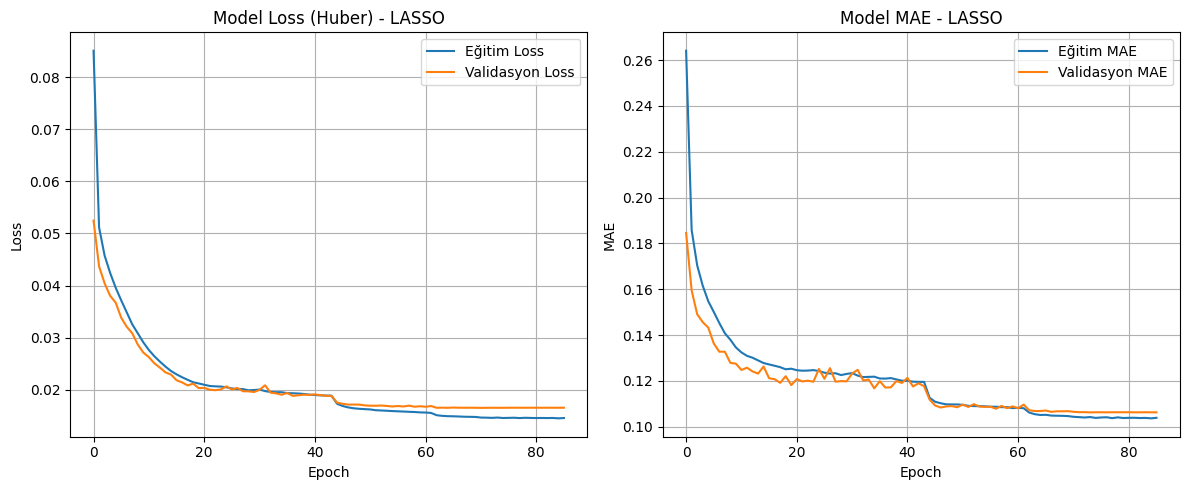

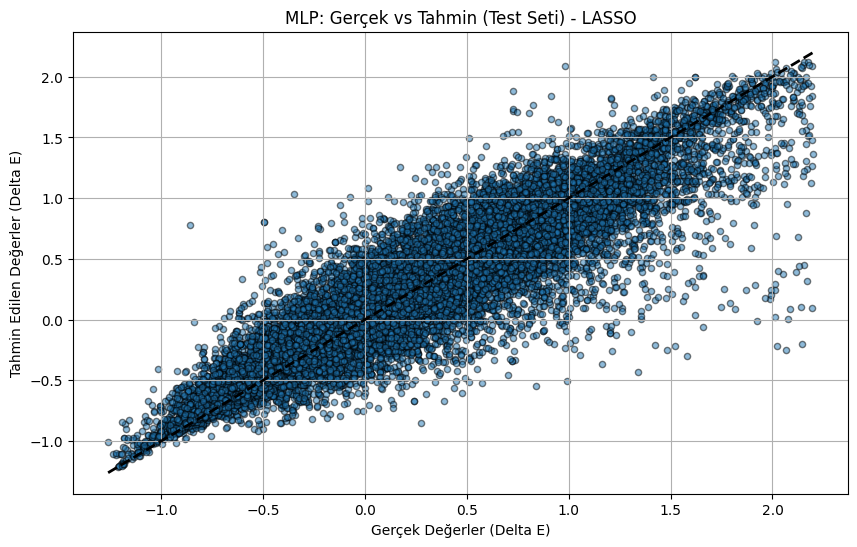

Ölçekleyici 'mlp_scaler_lasso.joblib' olarak kaydedildi.
Model özellikleri 'mlp_model_features_lasso.joblib' olarak kaydedildi.


In [4]:
#-------------------------------------------------------------------------------
# Blok 1 Çalıştırma
#-------------------------------------------------------------------------------
data_file_path = 'veri.csv'
trained_mlp_model, trained_final_scaler, selected_model_features = None, None, None

print("\n--- Blok 1: MLP Model Eğitimi (LASSO ile), Değerlendirmesi ve Kaydedilmesi ---")
if not os.path.exists(data_file_path):
    print(f"HATA: Veri dosyası '{data_file_path}' bulunamadı.")
else:
    trained_mlp_model_lasso, scaler_lasso_final, features_lasso = train_evaluate_save_mlp_model(
        data_path=data_file_path,
        feature_selection_method='lasso',
        lasso_alpha=0.0001,
        base_filename='mlp_delta_e_model', # Dosya adları için temel isim
        epochs=200,
        batch_size=1024,
        learning_rate=0.001,
        dropout_rate=0.1,
        l2_reg_val=1e-5
    )